# An options-chain pipeline you can trust in six months

Options research dies on data logistics before it dies on ideas. Historical chain
data is expensive; the free alternative is to *start recording now* — snapshot the
chain daily, store it in a shape you'll still understand later, and let history
accumulate. This repo is that machine: **fetch → tidy → store → derive**, deliberately
boring, engineered around three rules:

1. **One schema forever** (`snapshot.tidy_chain`): one row per contract, mid computed
   only when both quote sides are live, priceless contracts dropped at the door.
2. **Append-only storage** (`store.save_snapshot`): snapshots are facts about a
   moment; overwriting one requires saying `overwrite=True` out loud. A research
   input that can silently rewrite its own past is not a research input.
3. **Pure, tested features** (`features`): ATM IV, term structure and slope, skew,
   expected move, IV rank — every one a pure function tested against constructed
   chains with hand-known answers (21 tests, no network required).

This notebook runs entirely from the committed sample snapshot (2026-07-02, SPY and
QQQ, ~5,600 contracts) so it reproduces offline. The live path is one scheduled
command: `optpipe snapshot --tickers SPY,QQQ`.

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from optpipe import features
from optpipe.store import list_snapshots, load_snapshot

ASSETS = Path("..") / "assets"
ASSETS.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110

SAMPLE = "../data/sample"
print(list_snapshots(root=SAMPLE).to_string(index=False))

spy = load_snapshot("SPY", "2026-07-02", root=SAMPLE)
qqq = load_snapshot("QQQ", "2026-07-02", root=SAMPLE)
spy.head(3)

      date ticker  contracts
2026-07-02    QQQ       2534
2026-07-02    SPY       3056


,ticker,snapshot_date,spot,expiry,dte,option_type,strike,bid,ask,mid,last,iv,volume,open_interest,moneyness
0,SPY,2026-07-02,744.780029,2026-07-09,7,call,685.0,58.11,61.63,59.870,57.04,0.486089,1.0,3,0.919735
1,SPY,2026-07-02,744.780029,2026-07-09,7,call,695.0,48.14,51.65,49.895,39.92,0.422857,NaN,5,0.933161
2,SPY,2026-07-02,744.780029,2026-07-09,7,call,700.0,43.15,46.67,44.910,35.34,0.391486,NaN,5,0.939875


## 1. The derived features, one row per name

`snapshot_features` is the row a downstream signal would consume — this is the
hand-off point to the other repos (IV-rank signals for
[honest-backtester](https://github.com/dmitridefreitas-dev/honest-backtester), real
smiles for [options-pricing-lib](https://github.com/dmitridefreitas-dev/options-pricing-lib)'s
surface builder). `iv_rank` is honestly NaN today: it *requires* history, and one
snapshot has none — the entire reason the pipeline stores rather than streams.

In [2]:
rows = {}
for name, chain in [("SPY", spy), ("QQQ", qqq)]:
    row = features.snapshot_features(chain)
    history_ivs = [row["atm_iv_30d"]]  # one day of history so far
    row["iv_rank"] = features.iv_rank(row["atm_iv_30d"], history_ivs)
    rows[name] = row
pd.DataFrame(rows).T.round(4)

,spot,atm_iv_30d,term_slope,skew_30d,expected_move_30d,iv_rank
SPY,744.78,0.1386,0.0143,0.0644,0.0306,NaN
QQQ,712.60,0.2615,-0.0035,0.0513,0.0574,NaN


Reading the numbers (2026-07-02): QQQ's 30-day ATM vol (~26%) is nearly double
SPY's (~14%), its term structure is slightly *inverted* (near-dated vol over
far-dated — a mild stress signature) while SPY's slopes normally upward, and both
carry the classic equity skew: downside protection priced 5–6 vol points over upside
participation. The options market is telling you, precisely, where it is nervous.

## 2. The term structure and the smile, from stored data

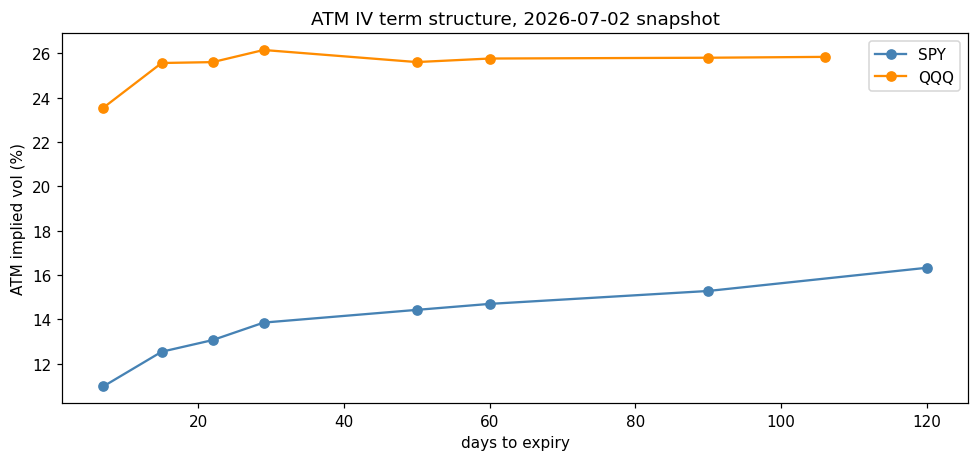

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.3))
for name, chain, color in [("SPY", spy, "steelblue"), ("QQQ", qqq, "darkorange")]:
    ts = features.term_structure(chain).dropna(subset=["atm_iv"])
    ax.plot(ts["dte"], 100 * ts["atm_iv"], marker="o", label=name, color=color)
ax.set_xlabel("days to expiry")
ax.set_ylabel("ATM implied vol (%)")
ax.set_title("ATM IV term structure, 2026-07-02 snapshot")
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / "term_structure.png", bbox_inches="tight")
plt.show()

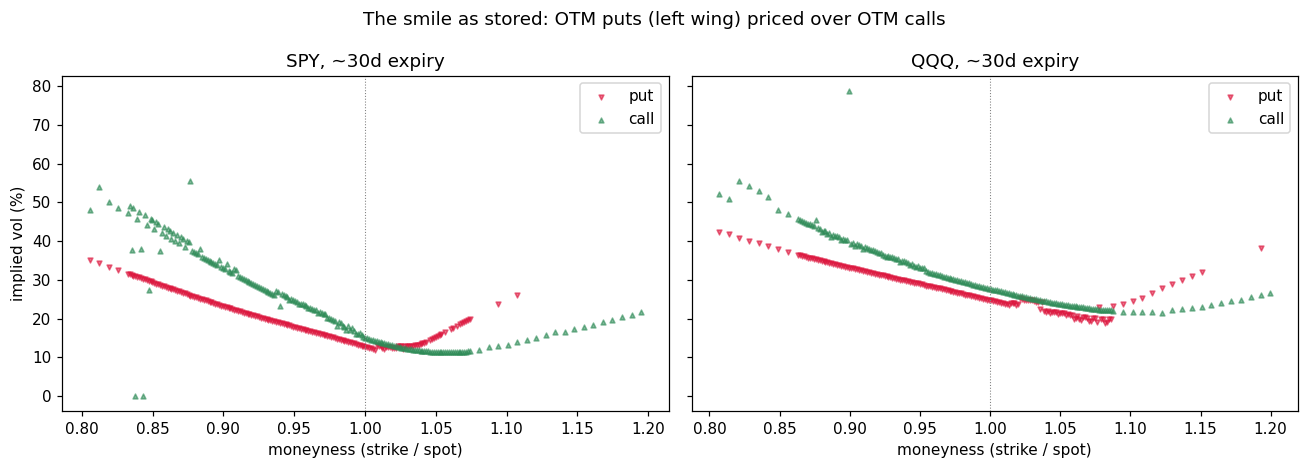

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for ax, (name, chain) in zip(axes, [("SPY", spy), ("QQQ", qqq)]):
    ts = features.term_structure(chain)
    expiry_30d = ts.iloc[(ts["dte"] - 30).abs().argmin()]["expiry"]
    month = chain[(chain["expiry"] == expiry_30d) & chain["iv"].notna()]
    month = month[(month["moneyness"] > 0.8) & (month["moneyness"] < 1.2)]
    for option_type, marker, color in [("put", "v", "crimson"), ("call", "^", "seagreen")]:
        side = month[month["option_type"] == option_type]
        ax.scatter(side["moneyness"], 100 * side["iv"], s=10, marker=marker,
                   color=color, alpha=0.6, label=option_type)
    ax.axvline(1.0, color="gray", lw=0.7, ls=":")
    ax.set_xlabel("moneyness (strike / spot)")
    ax.set_title(f"{name}, ~30d expiry")
    ax.legend()
axes[0].set_ylabel("implied vol (%)")
fig.suptitle("The smile as stored: OTM puts (left wing) priced over OTM calls")
fig.tight_layout()
fig.savefig(ASSETS / "smiles.png", bbox_inches="tight")
plt.show()

## 3. Running it for real

```bash
# one-time
pip install -e .

# every close (or on a schedule)
optpipe snapshot --tickers SPY,QQQ
optpipe list
optpipe features --ticker SPY
```

Scheduling on Windows (Task Scheduler) — daily at 16:45 ET:

```
schtasks /Create /SC DAILY /ST 16:45 /TN optpipe ^
    /TR "optpipe snapshot --tickers SPY,QQQ"
```

or cron: `45 16 * * 1-5 optpipe snapshot --tickers SPY,QQQ`.

One design point worth noticing: liquid ETFs now list *daily* expirations, so
"fetch the first N expiries" silently collects two weeks of near-dated noise and no
term structure at all (found the hard way — the first live run returned
`term_slope = NaN`). The fetcher instead targets days-to-expiry
(7, 14, 21, 30, 45, 60, 90, 120 by default) and takes the nearest distinct expiry to
each, so every snapshot spans the curve compactly.

## 4. Honesty notes and next steps

- **This is delayed retail data.** yfinance IVs and quotes are indicative, not NBBO;
  fine for daily-frequency research features, unusable for microstructure work.
- **IV rank needs patience by design** — it reports NaN until the store has history.
  No shortcut exists that isn't lookahead in disguise.
- **Next steps:** wire the accumulated ATM-IV history into an IV-rank
  mean-reversion study in honest-backtester (the study that repo deferred for lack
  of exactly this data); invert stored mids through options-pricing-lib's solver to
  compare model-free yfinance IVs against Black-Scholes-implied ones; add more
  tickers and a retention policy once the store grows.